In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [91]:
df=pd.read_csv("Electric_Vehicle_Population_Data.csv")

In [92]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5UXTA6C03P,King,Seattle,WA,98177.0,2023,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30,0,36.0,218985539,POINT (-122.38242499999996 47.77279000000004),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
1,1FMCU0EZXN,Yakima,Moxee,WA,98936.0,2022,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,15.0,197264322,POINT (-120.37951169999997 46.55609000000004),PACIFICORP,5.307700e+10
2,1G1FW6S03J,King,Seattle,WA,98117.0,2018,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,36.0,168549727,POINT (-122.37275999999997 47.689685000000054),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
3,5YJSA1AC0D,King,Newcastle,WA,98059.0,2013,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208,69900,41.0,244891062,POINT (-122.15733999999998 47.487175000000036),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,1FADP5CU8F,Kitsap,Bremerton,WA,98312.0,2015,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,26.0,134915000,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303508e+10


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143596 entries, 0 to 143595
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         143596 non-null  object 
 1   County                                             143574 non-null  object 
 2   City                                               143574 non-null  object 
 3   State                                              143596 non-null  object 
 4   Postal Code                                        143574 non-null  float64
 5   Model Year                                         143596 non-null  int64  
 6   Make                                               143596 non-null  object 
 7   Model                                              143596 non-null  object 
 8   Electric Vehicle Type                              143596 non-null  object

In [94]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,143574.000000,143596.000000,143596.000000,143596.000000,143269.000000,1.435960e+05,1.435740e+05
mean,98175.212824,2019.865574,70.495738,1373.386515,29.371748,2.092015e+08,5.297590e+10
std,2383.169088,3.016004,97.128735,9450.067747,14.823899,8.353700e+07,1.594040e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.081042e+09
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,1.668338e+08,5.303301e+10
50%,98122.000000,2021.000000,19.000000,0.000000,33.000000,2.111039e+08,5.303303e+10
75%,98370.000000,2022.000000,111.000000,0.000000,43.000000,2.364520e+08,5.305307e+10
max,99403.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


In [95]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                22
City                                                  22
State                                                  0
Postal Code                                           22
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 327
DOL Vehicle ID                                         0
Vehicle Location                                      25
Electric Utility                                      22
2020 Census Tract                                     22
dtype: int64

In [96]:
#cleaning part of null values in this dataset
df['County'] = df['County'].fillna(df['County'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])
df['Electric Utility'] = df['Electric Utility'].fillna(df['Electric Utility'].mode()[0])

In [97]:
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].median())
df['Legislative District'] = df['Legislative District'].fillna(df['Legislative District'].median())
df['2020 Census Tract'] = df['2020 Census Tract'].fillna(df['2020 Census Tract'].median())

In [98]:
df['Vehicle Location'] = df['Vehicle Location'].fillna(
    df['Vehicle Location'].mode()[0]
)

In [99]:
df.isnull().sum()

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64

In [100]:
#1.How many electric vehicles are recorded in the dataset?
a=len(df)
a

143596

In [101]:
#2. How many unique EV manufacturers (Make) are present in the dataset?
df['Make'].unique()

array(['BMW', 'FORD', 'CHEVROLET', 'TESLA', 'VOLVO', 'NISSAN', 'KIA',
       'AUDI', 'TOYOTA', 'RIVIAN', 'HONDA', 'PORSCHE', 'JEEP', 'CHRYSLER',
       'HYUNDAI', 'FIAT', 'VOLKSWAGEN', 'MITSUBISHI', 'MERCEDES-BENZ',
       'LUCID', 'MINI', 'GENESIS', 'MAZDA', 'TH!NK', 'CADILLAC', 'SUBARU',
       'LEXUS', 'LINCOLN', 'SMART', 'JAGUAR', 'POLESTAR', 'LAND ROVER',
       'FISKER', 'AZURE DYNAMICS', 'ALFA ROMEO', 'WHEEGO ELECTRIC CARS',
       'BENTLEY'], dtype=object)

In [102]:
#3. Which manufacturer has the highest number of registered electric vehicles?
df['Make'].value_counts().idxmax()

'TESLA'

In [103]:
#4.What are the top 10 EV manufacturers based on the number of vehicles?
top_10=df['Make'].value_counts().head(10)
top_10

Make
TESLA         65552
NISSAN        13317
CHEVROLET     11816
FORD           7307
BMW            6209
KIA            5922
TOYOTA         5074
VOLKSWAGEN     3914
VOLVO          3415
JEEP           3084
Name: count, dtype: int64

In [104]:
 #5.How many Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) are there?
vehicle_types=df['Electric Vehicle Type'].value_counts()
vehicle_types

Electric Vehicle Type
Battery Electric Vehicle (BEV)            110865
Plug-in Hybrid Electric Vehicle (PHEV)     32731
Name: count, dtype: int64

In [105]:
#6.What percentage of the total vehicles are BEVs and PHEVs?
total_vehicle=len(df)

BEVs_count=(df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)').sum()
PHEV_count=(df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)').sum()


percentage_BEVs=(BEVs_count/total_vehicle)*100
percentage_PHEV=(PHEV_count/total_vehicle)*100
 

In [106]:
percentage_BEVs

np.float64(77.2061895874537)

In [107]:
percentage_PHEV

np.float64(22.79381041254631)

In [108]:
#7.What is the average electric range of all vehicles in the dataset?
df['Electric Range'].mean()

np.float64(70.49573804284242)

In [109]:
#8.Which vehicle has the maximum electric range, and what is that range?
max_vehicle = df.loc[df['Electric Range'].idxmax()]
print(max_vehicle[['Make', 'Model', 'Model Year', 'Electric Range']])

Make                TESLA
Model             MODEL S
Model Year           2020
Electric Range        337
Name: 6982, dtype: object


In [110]:
#9.What are the top 10 cities with the highest EV population?
a=(df['City'].value_counts()).head(10)
a

City
Seattle      24684
Bellevue      7376
Redmond       5245
Vancouver     5045
Bothell       4599
Kirkland      4455
Sammamish     4199
Renton        3744
Olympia       3396
Tacoma        2975
Name: count, dtype: int64

In [111]:
#10.Which county has the highest number of registered electric vehicles?
a=(df['County'].value_counts()).idxmax()   # it give column highest one like 'King'
a

'King'

In [112]:
a=(df['County'].value_counts()).max()         # it will give count  of that country
a

np.int64(75405)

In [113]:
#11.Which state has the highest number of electric vehicles?
highest_state=df['State'].value_counts().idxmax()
highest_state

'WA'

In [114]:
#12.What are the top 10 most popular EV models?
top_10_EV_Models=(df['Model'].value_counts()).head(10)

In [115]:
top_10_EV_Models

Model
MODEL 3        26766
MODEL Y        26194
LEAF           13093
MODEL S         7542
BOLT EV         5599
MODEL X         5002
VOLT            4884
ID.4            2839
NIRO            2764
PRIUS PRIME     2506
Name: count, dtype: int64

In [116]:
#13.Which EV model is the most frequently registered?
EV_Model_frequently_registered=df['Model'].mode()
EV_Model_frequently_registered

0    MODEL 3
Name: Model, dtype: object

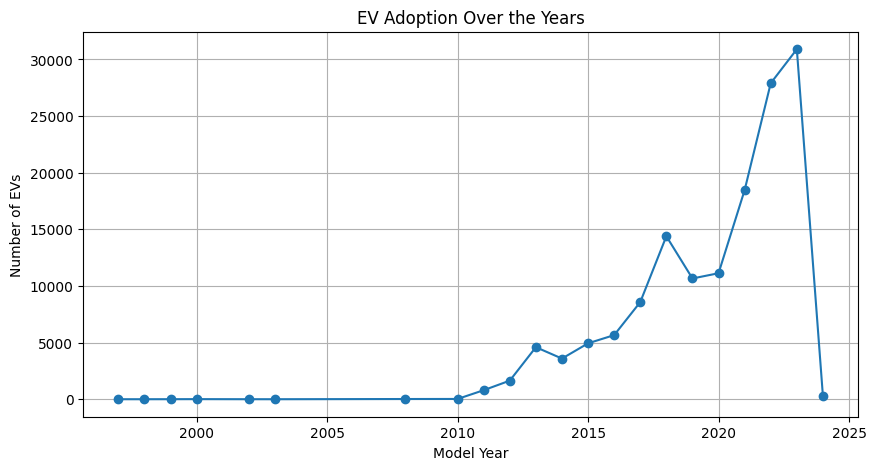

In [117]:
#14.How has EV adoption changed over the years based on the Model Year column

ev_by_year = df['Model Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(ev_by_year.index, ev_by_year.values, marker='o')
plt.title('EV Adoption Over the Years')
plt.xlabel('Model Year')
plt.ylabel('Number of EVs')
plt.grid(True)
plt.show()

In [118]:
#15. Which model year recorded the highest number of EV registrations?
ev_by_year = (df['Model Year'].value_counts()).idxmax()

In [119]:
ev_by_year

np.int64(2023)

In [120]:
#16. What is the average electric range for each vehicle manufacturer?
avg_EV_vehicle=df.groupby('Make')['Electric Range'].mean()
avg_EV_vehicle

Make
ALFA ROMEO               33.000000
AUDI                     54.013103
AZURE DYNAMICS           56.000000
BENTLEY                  18.666667
BMW                      38.967306
CADILLAC                 23.678322
CHEVROLET                95.242552
CHRYSLER                 32.259364
FIAT                     85.626683
FISKER                   33.000000
FORD                     13.589845
GENESIS                   0.000000
HONDA                    46.668727
HYUNDAI                  25.882580
JAGUAR                  205.281818
JEEP                     22.337549
KIA                      53.957447
LAND ROVER               21.909091
LEXUS                    28.207921
LINCOLN                  23.559471
LUCID                     0.000000
MAZDA                    26.000000
MERCEDES-BENZ            10.970772
MINI                     21.542746
MITSUBISHI               29.326223
NISSAN                   85.848089
POLESTAR                 56.224949
PORSCHE                  47.549550
RIVIAN         

In [121]:
#17. Which manufacturer offers the highest average electric range?
avg_EV_vehicle_highest_average=(df.groupby('Make')['Electric Range'].mean()).idxmax()
avg_EV_vehicle_highest_average

'JAGUAR'

In [122]:
#18. What is the distribution of Clean Alternative Fuel Vehicle (CAFV) eligibility among vehicles?
df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    63954
Clean Alternative Fuel Vehicle Eligible                         62149
Not eligible due to low battery range                           17493
Name: count, dtype: int64

In [123]:
#19. Is there a relationship between Base MSRP and Electric Range?
df['Base MSRP'].corr(df['Electric Range'])

np.float64(0.10177106306176939)

In [124]:
#20. What is the average electric range of BEVs compared to PHEVs?
df.groupby('Electric Vehicle Type')['Electric Range'].mean()

Electric Vehicle Type
Battery Electric Vehicle (BEV)            82.263825
Plug-in Hybrid Electric Vehicle (PHEV)    30.635392
Name: Electric Range, dtype: float64

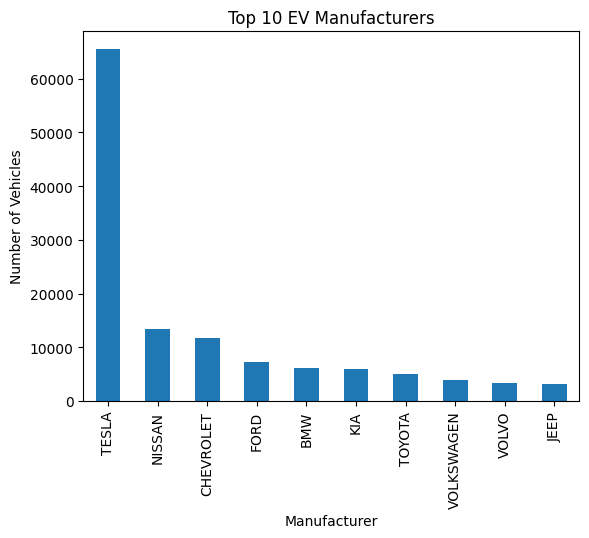

In [125]:
# Top 10 EV Manufacturers
top_10_makes = df['Make'].value_counts().head(10)

top_10_makes.plot(kind='bar')
plt.title('Top 10 EV Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Vehicles')
plt.show()

In [126]:
# BEV vs PHEV Distribution
df['Electric Vehicle Type'].value_counts()

Electric Vehicle Type
Battery Electric Vehicle (BEV)            110865
Plug-in Hybrid Electric Vehicle (PHEV)     32731
Name: count, dtype: int64

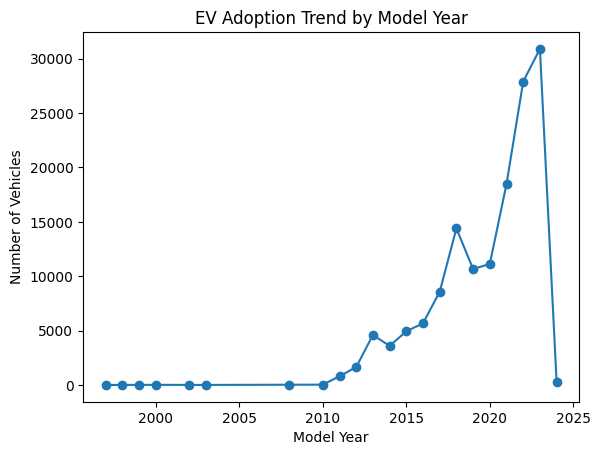

In [127]:
# EV Adoption Trend by Model Year
ev_by_year = df['Model Year'].value_counts().sort_index()

ev_by_year.plot(kind='line', marker='o')
plt.title('EV Adoption Trend by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of Vehicles')
plt.show()

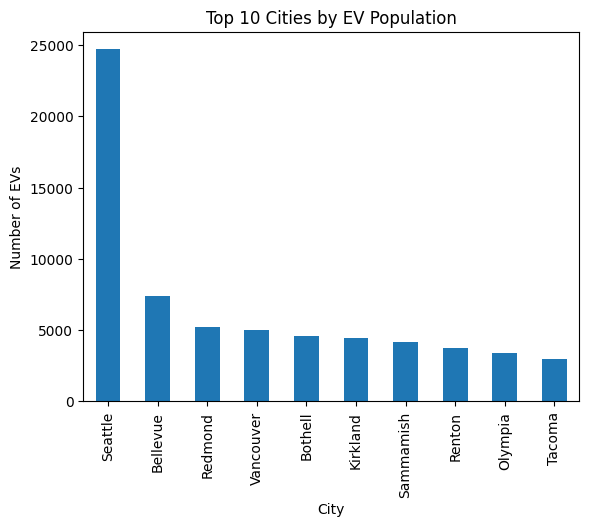

In [128]:
#Top 10 Cities with Highest EV Population
top_10_cities = df['City'].value_counts().head(10)

top_10_cities.plot(kind='bar')
plt.title('Top 10 Cities by EV Population')
plt.xlabel('City')
plt.ylabel('Number of EVs')
plt.show()